<a href="https://colab.research.google.com/github/bsuprava/MLOpsTourism/blob/main/tourism_package_predictionv2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem Statement

## **Business Context**

"Visit with Us," a leading travel company, is revolutionizing the tourism industry by leveraging data-driven strategies to optimize operations and customer engagement. While introducing a new package offering, such as the Wellness Tourism Package, the company faces challenges in targeting the right customers efficiently. The manual approach to identifying potential customers is inconsistent, time-consuming, and prone to errors, leading to missed opportunities and suboptimal campaign performance.

To address these issues, the company aims to implement a scalable and automated system that integrates customer data, predicts potential buyers, and enhances decision-making for marketing strategies. By utilizing an MLOps pipeline, the company seeks to achieve seamless integration of data preprocessing, model development, deployment, and CI/CD practices for continuous improvement. This system will ensure efficient targeting of customers, timely updates to the predictive model, and adaptation to evolving customer behaviors, ultimately driving growth and customer satisfaction.


## **Objective**

As an MLOps Engineer at "Visit with Us," your responsibility is to design and deploy an MLOps pipeline on GitHub to automate the end-to-end workflow for predicting customer purchases. The primary objective is to build a model that predicts whether a customer will purchase the newly introduced Wellness Tourism Package before contacting them. The pipeline will include data cleaning, preprocessing, transformation, model building, training, evaluation, and deployment, ensuring consistent performance and scalability. By leveraging GitHub Actions for CI/CD integration, the system will enable automated updates, streamline model deployment, and improve operational efficiency. This robust predictive solution will empower policymakers to make data-driven decisions, enhance marketing strategies, and effectively target potential customers, thereby driving customer acquisition and business growth.

## **Data Description**

The dataset contains customer and interaction data that serve as key attributes for predicting the likelihood of purchasing the Wellness Tourism Package. The detailed attributes are:

**Customer Details**
- **CustomerID:** Unique identifier for each customer.
- **ProdTaken:** Target variable indicating whether the customer has purchased a package (0: No, 1: Yes).
- **Age:** Age of the customer.
- **TypeofContact:** The method by which the customer was contacted (Company Invited or Self Inquiry).
- **CityTier:** The city category based on development, population, and living standards (Tier 1 > Tier 2 > Tier 3).
- **Occupation:** Customer's occupation (e.g., Salaried, Freelancer).
- **Gender:** Gender of the customer (Male, Female).
- **NumberOfPersonVisiting:** Total number of people accompanying the customer on the trip.
- **PreferredPropertyStar:** Preferred hotel rating by the customer.
- **MaritalStatus:** Marital status of the customer (Single, Married, Divorced).
- **NumberOfTrips:** Average number of trips the customer takes annually.
- **Passport:** Whether the customer holds a valid passport (0: No, 1: Yes).
- **OwnCar:** Whether the customer owns a car (0: No, 1: Yes).
- **NumberOfChildrenVisiting:** Number of children below age 5 accompanying the customer.
- **Designation:** Customer's designation in their current organization.
- **MonthlyIncome:** Gross monthly income of the customer.

**Customer Interaction Data**
- **PitchSatisfactionScore:** Score indicating the customer's satisfaction with the sales pitch.
- **ProductPitched:** The type of product pitched to the customer.
- **NumberOfFollowups:** Total number of follow-ups by the salesperson after the sales pitch.-
- **DurationOfPitch:** Duration of the sales pitch delivered to the customer.


# 1. Install Necessary Libraries

In [ ]:
#Installing the libraries with the specified versions
!pip install \
    numpy \
    pandas \
    scikit-learn \
    imbalanced-learn \
    matplotlib \
    seaborn \
    joblib \
    xgboost \
    catboost \
    requests \
    huggingface_hub \
    -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.9 MB/s eta 0:00:00


In [ ]:
!pip install Flask

In [ ]:
!pip install streamlit

In [ ]:
# Libraries to help with reading and manipulating data
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd

# Libaries to help with data visualization
import matplotlib      # Makes the 'matplotlib' name available
import matplotlib.pyplot as plt # Makes the 'plt' name available
import seaborn as sns

print(f"numpy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"matplotlib version: {matplotlib.__version__}")
print(f"seaborn version: {sns.__version__}")

numpy version: 2.0.2
Pandas version: 2.2.2
matplotlib version: 3.10.0
seaborn version: 0.13.2


# 2. Data Overview
## 2.1. Load Dataset and Display

In [ ]:
# Load Dataset
tourismdf = pd.read_csv("/content/sample_data/tourism.csv",low_memory=False)

# Data Overview:
print("Data Overview:-")
print("There are", tourismdf.shape[0], 'rows and', tourismdf.shape[1], "columns.")
if tourismdf.shape[0] > 10:
    print("Displaying first 10 rows of data:-")
    print(tourismdf.head(10))

Data Overview:-
There are 4128 rows and 21 columns.
Displaying first 10 rows of data:-
   Unnamed: 0  CustomerID  ProdTaken  Age    TypeofContact  CityTier  \
0           0      200000          1   41     Self Enquiry         3   
1           1      200001          0   49  Company Invited         1   
2           2      200002          1   37     Self Enquiry         1   
3           3      200003          0   33  Company Invited         1   
4           5      200005          0   32  Company Invited         1   
5           6      200006          0   59     Self Enquiry         1   
6           7      200007          0   30     Self Enquiry         1   
7           8      200008          0   38  Company Invited         1   
8           9      200009          0   36     Self Enquiry         1   
9          10      200010          0   35     Self Enquiry         1   

   DurationOfPitch      Occupation  Gender  NumberOfPersonVisiting  ...  \
0                6        Salaried  Female   

In [ ]:
print("Column attribute info: ",tourismdf.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4128 entries, 0 to 4127
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Unnamed: 0                4128 non-null   int64 
 1   CustomerID                4128 non-null   int64 
 2   ProdTaken                 4128 non-null   int64 
 3   Age                       4128 non-null   int64 
 4   TypeofContact             4128 non-null   object
 5   CityTier                  4128 non-null   int64 
 6   DurationOfPitch           4128 non-null   int64 
 7   Occupation                4128 non-null   object
 8   Gender                    4128 non-null   object
 9   NumberOfPersonVisiting    4128 non-null   int64 
 10  NumberOfFollowups         4128 non-null   int64 
 11  ProductPitched            4128 non-null   object
 12  PreferredPropertyStar     4128 non-null   int64 
 13  MaritalStatus             4128 non-null   object
 14  NumberOfTrips           

**Overview**
* The dataset contains 15 numerical columns and 6 categorical/object type columns.
* Our target feature is ProdTaken which contains value 0 or 1.
* One Unnamed column and CustomerID columns are not useful features for the prediction and therefore recommeded to remove them.

In [ ]:
# Create a copy of the dataframe
tdf = tourismdf.copy()
# Drop the unique identifier Unnamed column and CustomerID
columns_to_drop = ['CustomerID', 'Unnamed: 0']
# Check which columns actually exist before dropping to avoid errors
existing_columns_to_drop = [col for col in columns_to_drop if col in tdf.columns]
if existing_columns_to_drop:
    tdf = tdf.drop(columns=existing_columns_to_drop)

In [ ]:
print("The unique values for categorical variables are displayed here")
# list of all categorical variables
cat_col = tourismdf.select_dtypes(include="object").columns.tolist()
# printing the number of occurrences of each unique value in each categorical column
for column in cat_col:
    print(tourismdf[column].value_counts(normalize=True))
    print("-" * 50)

The unique values for categorical variables are displayed here
TypeofContact
Self Enquiry       0.70688
Company Invited    0.29312
Name: proportion, dtype: float64
--------------------------------------------------
Occupation
Salaried          0.484254
Small Business    0.422965
Large Business    0.092297
Free Lancer       0.000484
Name: proportion, dtype: float64
--------------------------------------------------
Gender
Male       0.596657
Female     0.365795
Fe Male    0.037548
Name: proportion, dtype: float64
--------------------------------------------------
ProductPitched
Basic           0.391231
Deluxe          0.344477
Standard        0.178537
Super Deluxe    0.060562
King            0.025194
Name: proportion, dtype: float64
--------------------------------------------------
MaritalStatus
Married      0.482074
Divorced     0.191134
Unmarried    0.165213
Single       0.161579
Name: proportion, dtype: float64
--------------------------------------------------
Designation
Executive

**Observation**
* The Gender column contains three categories; however, the categories "Female" and "Fe Male" refer to the same category as "Female". So the category name must be corrected for further analysis and reporting to avoid any unreliable predictions.
* The categories unmarried and single in the MaritalStatus column both practically mean the person does not have a spouse. So combining them reduces noise.

## 2.2 Treat equivalent category values

In [ ]:
# 2. Map the specific 'Fe Male' error
tdf['Gender'] = tdf['Gender'].replace({'Fe Male': 'Female'})
print(tdf['Gender'].value_counts(normalize=True))

Gender
Male      0.596657
Female    0.403343
Name: proportion, dtype: float64


In [ ]:
# Merge Single and Unmarried into a single category
tdf['MaritalStatus'] = tdf['MaritalStatus'].replace({
    'Single': 'Unmarried'
})
print(tdf['MaritalStatus'].value_counts(normalize=True))

MaritalStatus
Married      0.482074
Unmarried    0.326793
Divorced     0.191134
Name: proportion, dtype: float64


## 2.3.Display Statistical Summary

In [ ]:
# Checking the statistical summary of numerical columns
print(tdf.describe().T)


                           count          mean          std     min      25%  \
ProdTaken                 4128.0      0.193072     0.394757     0.0      0.0   
Age                       4128.0     37.231831     9.174521    18.0     31.0   
CityTier                  4128.0      1.663275     0.920640     1.0      1.0   
DurationOfPitch           4128.0     15.584787     8.398142     5.0      9.0   
NumberOfPersonVisiting    4128.0      2.949370     0.718818     1.0      2.0   
NumberOfFollowups         4128.0      3.741521     1.006786     1.0      3.0   
PreferredPropertyStar     4128.0      3.578488     0.795031     3.0      3.0   
NumberOfTrips             4128.0      3.295300     1.856300     1.0      2.0   
Passport                  4128.0      0.295300     0.456233     0.0      0.0   
PitchSatisfactionScore    4128.0      3.060804     1.363064     1.0      2.0   
OwnCar                    4128.0      0.612161     0.487317     0.0      0.0   
NumberOfChildrenVisiting  4128.0      1.

In [ ]:
# Checking the statistical summary of categorical columns
print(tdf.describe(include=['object']).T)

               count unique           top  freq
TypeofContact   4128      2  Self Enquiry  2918
Occupation      4128      4      Salaried  1999
Gender          4128      2          Male  2463
ProductPitched  4128      5         Basic  1615
MaritalStatus   4128      3       Married  1990
Designation     4128      5     Executive  1615


## 2.4. Check Missing and Duplicate Values

In [ ]:
# Checking Missing Values in dataset
print("Total Missing Values per Column:\n", tourismdf.isnull().sum())

Total Missing Values per Column:
 Unnamed: 0                  0
CustomerID                  0
ProdTaken                   0
Age                         0
TypeofContact               0
CityTier                    0
DurationOfPitch             0
Occupation                  0
Gender                      0
NumberOfPersonVisiting      0
NumberOfFollowups           0
ProductPitched              0
PreferredPropertyStar       0
MaritalStatus               0
NumberOfTrips               0
Passport                    0
PitchSatisfactionScore      0
OwnCar                      0
NumberOfChildrenVisiting    0
Designation                 0
MonthlyIncome               0
dtype: int64


In [ ]:
# Checking Duplicate Values in dataset
print("Duplicate rows found:\n", tourismdf.duplicated().sum())

Duplicate rows found:
 0


## 2.5 Check Target Class Distribution

In [ ]:
# Count of each class
counts = tourismdf['ProdTaken'].value_counts()
print(counts)

# Proportion of each class
print(tourismdf['ProdTaken'].value_counts(normalize=True)*100)

imbalance_ratio = counts.max() / counts.min()
print(f"Imbalance Ratio: {imbalance_ratio:.2f}")

ProdTaken
0    3331
1     797
Name: count, dtype: int64
ProdTaken
0    80.692829
1    19.307171
Name: proportion, dtype: float64
Imbalance Ratio: 4.18


## 2.6. Visualize Target Class Imbalance

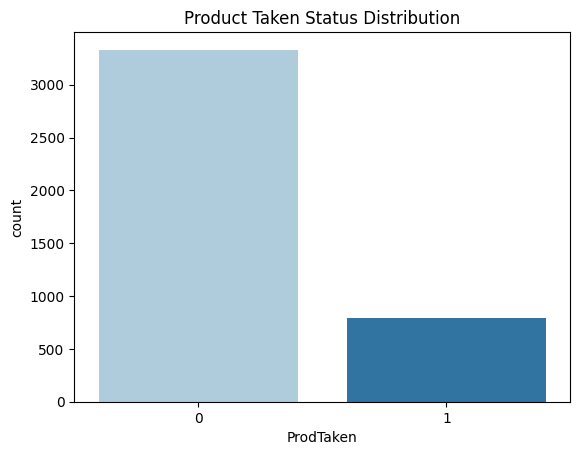

In [ ]:
sns.countplot(x='ProdTaken', data=tourismdf, palette="Paired")
plt.title('Product Taken Status Distribution')
plt.show()

**Observation**
* One class ProductTaken as No appears 4.18 times more frequently than the other.
* This indicates a moderate to high class imbalance, which needs to be treated to build the best model.
* We can use sampling techniques or use Models that can handle imbalance very well.
* Models such as Random Forest with class weights, XGBoost, or LightGBM can be a better choice.

# 3. EDA
## 3.1.Visualise Univariate Analysis
### 3.1.1. Displaying Histograms for Numerical Features

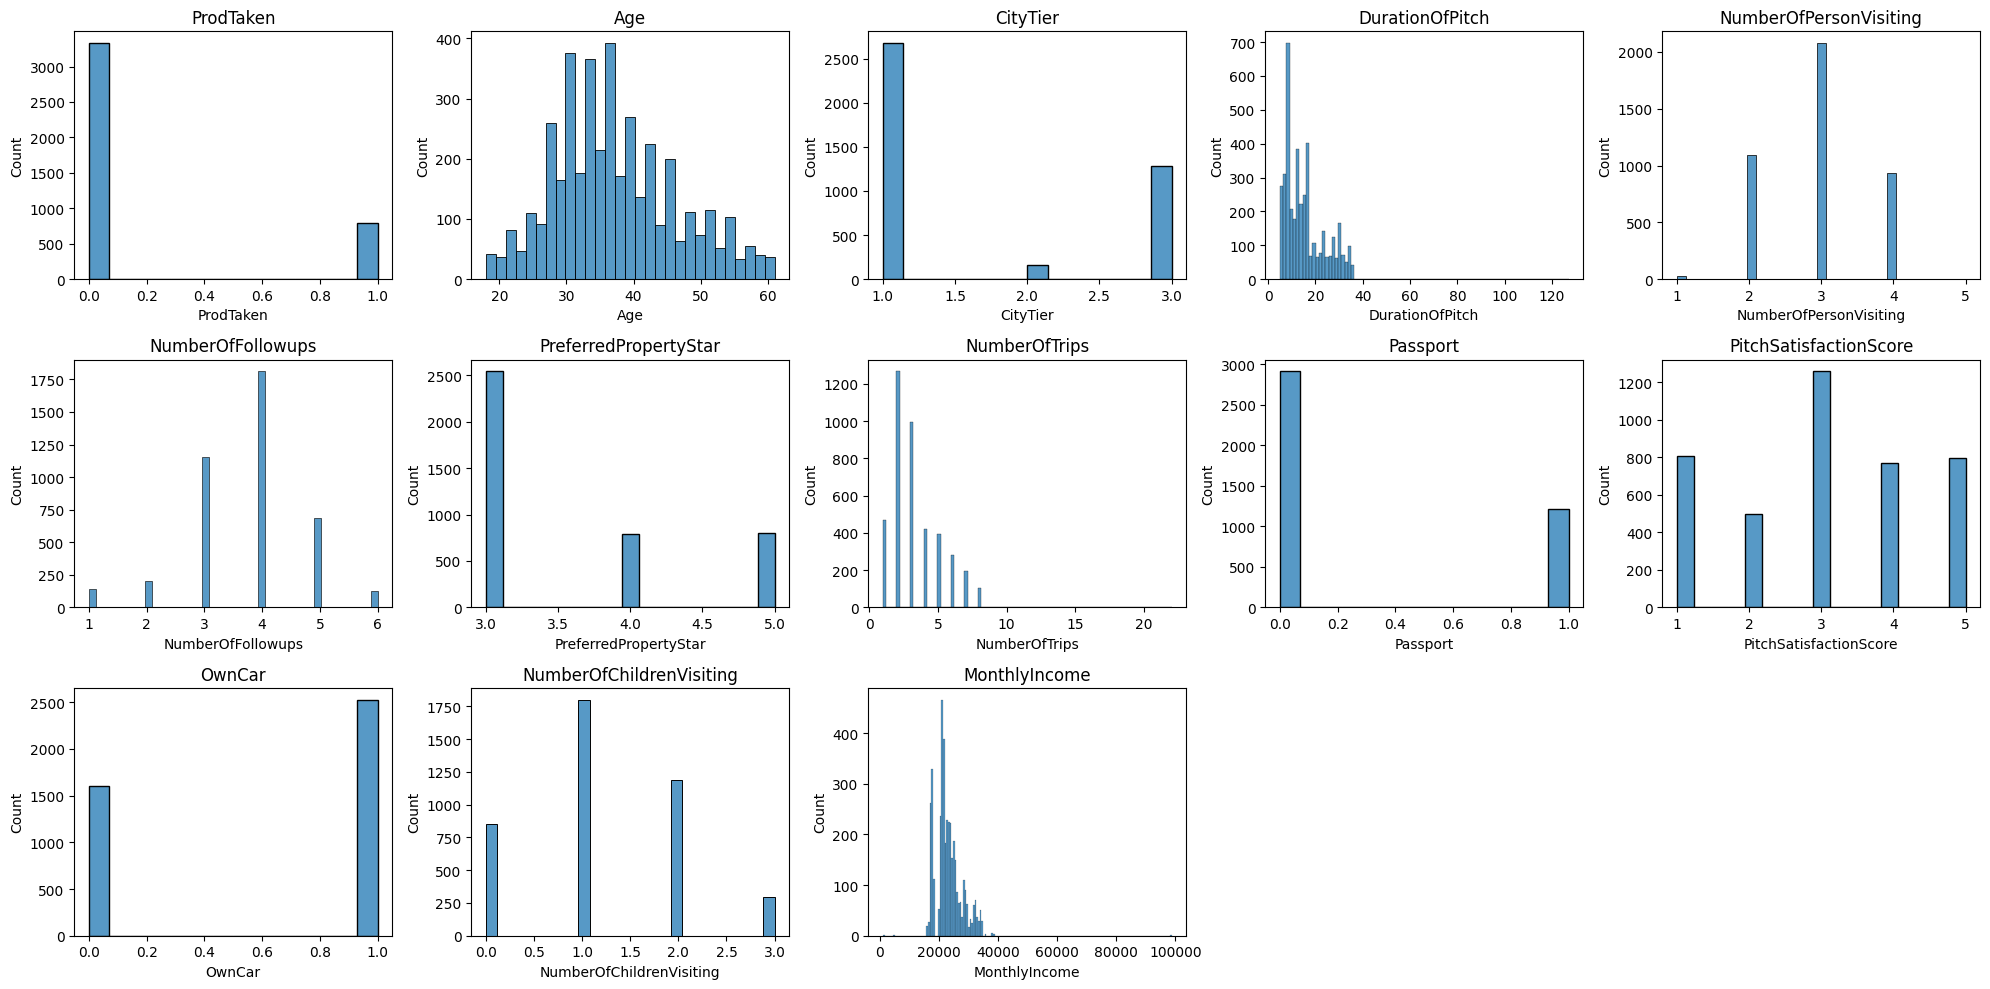

In [ ]:
# defining the figure size
plt.figure(figsize=(20, 10))

# defining the list of numerical features to plot
num_features = tdf.select_dtypes(include=['number']).columns.tolist()

# Use a 3-row, 5-column grid to accommodate 15 features
rows = 3
cols = 5

# creating the histograms
for i, feature in enumerate(num_features):
    # This check is a safeguard if the list is longer than 15 somehow
    if i >= rows * cols:
        print(f"Stopping plot generation at feature {i+1} as grid is full.")
        break

    # Assign a subplot using the 3x5 grid
    plt.subplot(rows, cols, i+1)
    sns.histplot(data=tdf, x=feature)    # plot the histogram
    plt.title(feature) # Add title to know which feature is which

plt.tight_layout()    # to add spacing between plots
plt.show()

**Observation**
* In the dataset, The age ranges from around 15 to 65. Most of the customers belong to 30 to 45 age group. The age chart is slightly right-skewed.
* There are customers from 3 types of city tiers. Tier1 customers are the highest among Tier2 and Tier3.
* DurationOfPitch: The duration of the sales pitch delivered to the customer is heavily right-skewed, with most values concentrated between 0 and 25 minutes, and only a few outliers going up to ~120 minutes.
* The total number of people accompanying the customer on the trip is generally 1 to 4, however, it is mostly 3 people.
* The total number of follow-ups by the salesperson after the sales pitch is generally 1 to 6, however, it is mostly 4 people.
* The preferred hotel rating by the customers is 3,4 or 5. The maximum rating given is 3, which is quite low.
* The average number of trips the customer takes annually is 2-8. Most of them take 3-4 times a year.
* Passport-holding customers are very few.
* Score indicating the customer's satisfaction with the sales pitch ranges from 1-5, and the highest score being 3.
* Customers as car owners is higher.
* The number of children below age 5 accompanying the customer ranges 0-3. Most of the customers have at least 1 child below the age of 5.
* The data shows the monthly income of customers ranges from about 18000 to 40000. It is highly right-skewed, indicating dense distribution between ~25000 to ~35000

### 3.1.2. Displaying Countplots for Categorical Features

In [ ]:
# function to create labeled barplots
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()

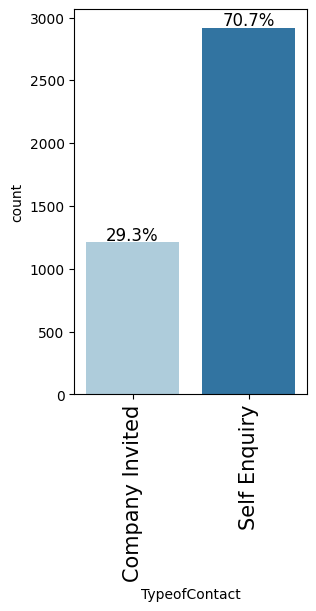

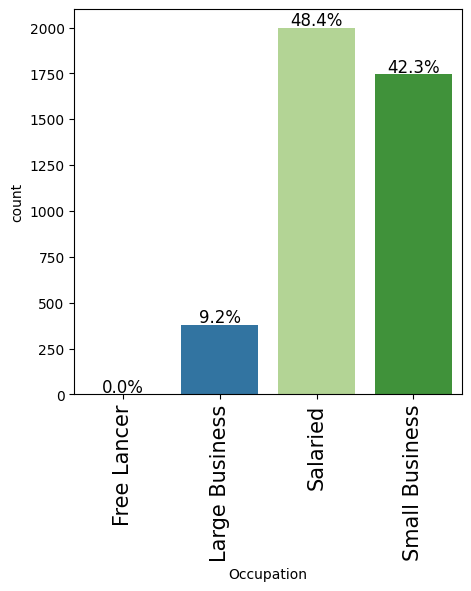

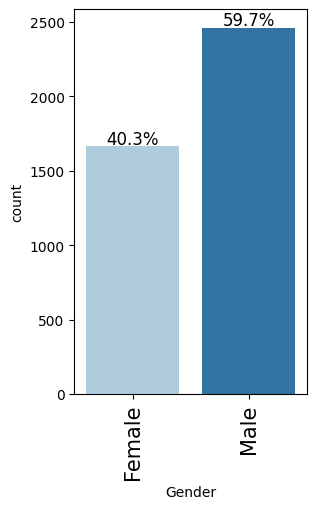

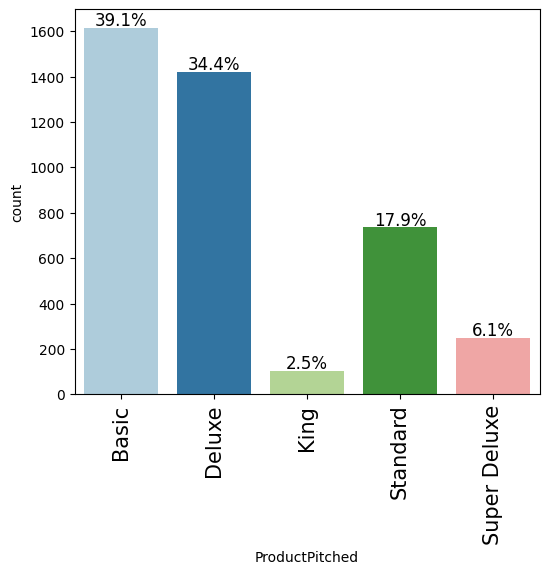

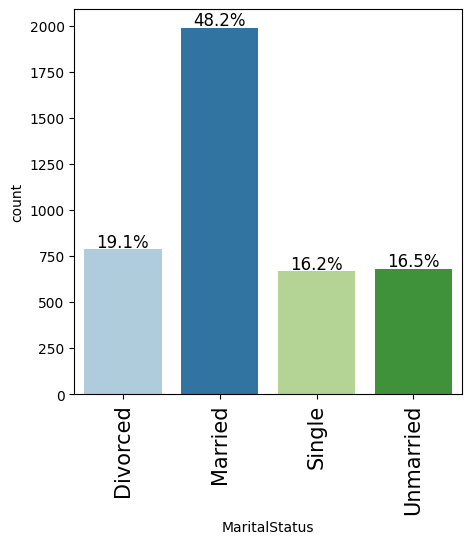

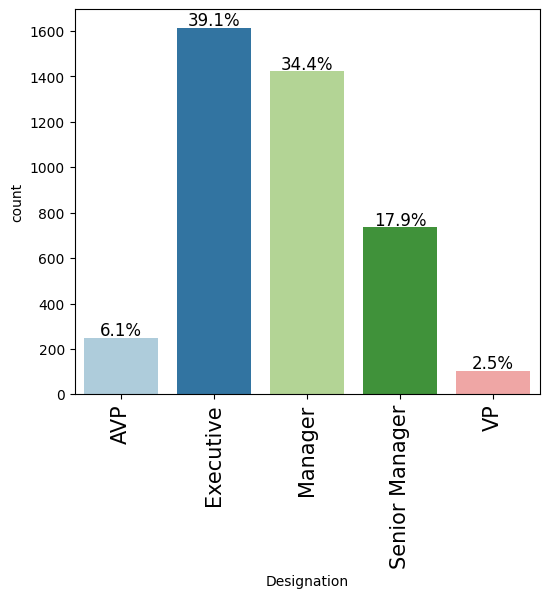

In [ ]:
# Plot the countplots in a loop
for i, feature in enumerate(cat_col):
        labeled_barplot(tdf, feature, perc=True)

**Observation**
* Around ~70 % customers were contacted through self-inquiry, and ~30% customers were invited by the Company.
* Almost ~48% customers are salaried, around ~42% of customers run small businesses.
* Only 9% customers have large businesses and very few customers are freelancers.
* About 60% customers are Male and 40% are Female.
* The type of product pitched to the customer mostly belongs to the basic category, around 39%, then deluxe, with ~43%, then the standard category, with ~17% and very few are of the superdeluxe category, with 6% and a minimum 2% as the King category.
* Most of the customers are married customers(48%).19% customers are divorced.
* Single and unmarried customers are 16% each.
* Executives and Managers are higher (with 39% and 34% respectively)
* Very few AVP(~6%) and VP(~2%) customers are there in record.

## 3.2.Visualise Bivariate Analysis of Categorical features

In [ ]:
def plot_bivariate_categorical_distribution(df, category_col, binary_col, title="Bivariate Distribution Plot"):
    """
    Generates and displays a count plot for the bivariate distribution
    between two categorical/binary columns.

    Args:
        df (pd.DataFrame): The input DataFrame.
        category_col (str): The name of the primary categorical column (e.g., 'Gender').
        binary_col (str): The name of the secondary binary/categorical column (e.g., 'Product Purchased').
        title (str): The title for the generated plot.
    """

    # Ensure the binary column has descriptive labels for better visualization (optional but recommended)
    df_temp = df.copy()
    if set(df_temp[binary_col].unique()) == {0, 1}:
        df_temp[binary_col] = df_temp[binary_col].map({0: 'No Purchase', 1: 'Yes Purchase'})

    # Use Seaborn's catplot (figure-level interface for categorical plots)
    # The 'kind="count"' automatically counts occurrences
    # 'hue' separates the bars by the second variable
    g = sns.catplot(
        x=category_col,
        hue=binary_col,
        data=df_temp,
        kind="count",
        height=6,
        aspect=1.2,
        palette="Paired"
    )

    # Set titles and labels
    g.fig.suptitle(title, y=1.03, fontsize=16)
    g.set_axis_labels(category_col.capitalize(), "Count of Customers")
    g.add_legend(title=binary_col.capitalize())

    # Optional: Add counts to the top of the bars for clarity
    ax = g.ax
    for p in ax.patches:
        ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points')

    plt.show()


In [ ]:
def plot_categorical_distribution(df, category_col, binary_col, title="Distribution Plot"):
    """
    Generates and displays a stacked bar chart for a categorical column
    against a binary purchase column (0=No, 1=Yes).

    Args:
        df (pd.DataFrame): The input DataFrame.
        category_col (str): The name of the categorical column (e.g., 'Gender').
        binary_col (str): The name of the binary numerical column (0/1).
        title (str): The title for the generated plot.
    """

    # Map 0/1 to descriptive labels if they exist in the binary column
    # We check if 0/1 are the only values to decide the mapping
    if set(df[binary_col].unique()) == {0, 1}:
        df_temp = df.copy()
        df_temp[binary_col] = df_temp[binary_col].map({0: 'No Purchase', 1: 'Yes Purchase'})
    else:
        # Use existing labels if they aren't standard 0/1
        df_temp = df.copy()

    # Create cross-tabulation table (counts)
    cross_tab = pd.crosstab(df_temp[category_col], df_temp[binary_col])

    # Plot the stacked bar chart
    ax = cross_tab.plot(kind='bar', stacked=True, figsize=(9, 6), rot=0,
                        color=['salmon', 'skyblue', 'lightgreen', 'orange'])

    # Add labels and title
    plt.title(title, fontsize=16)
    plt.xlabel(category_col.capitalize(), fontsize=12)
    plt.ylabel('Count of Customers', fontsize=12)
    plt.legend(title=binary_col, bbox_to_anchor=(1.05, 1), loc='upper left')

    # Add value labels on the bars for clarity
    for container in ax.containers:
        ax.bar_label(container, label_type='center', fmt='%d')

    # Adjust layout and display
    plt.tight_layout()
    plt.show()


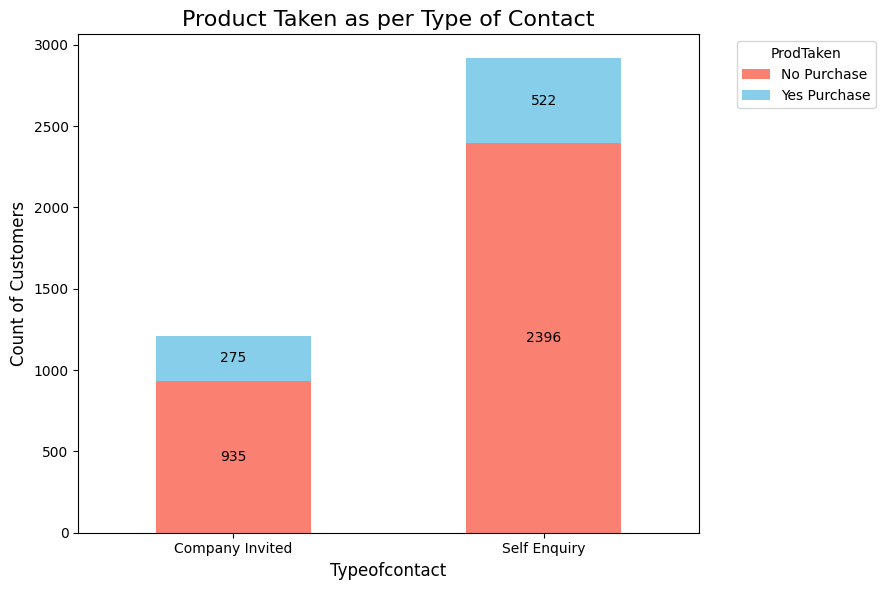

In [ ]:
plot_categorical_distribution(
    df=tdf,
    category_col='TypeofContact',
    binary_col='ProdTaken',
    title='Product Taken as per Type of Contact'
)

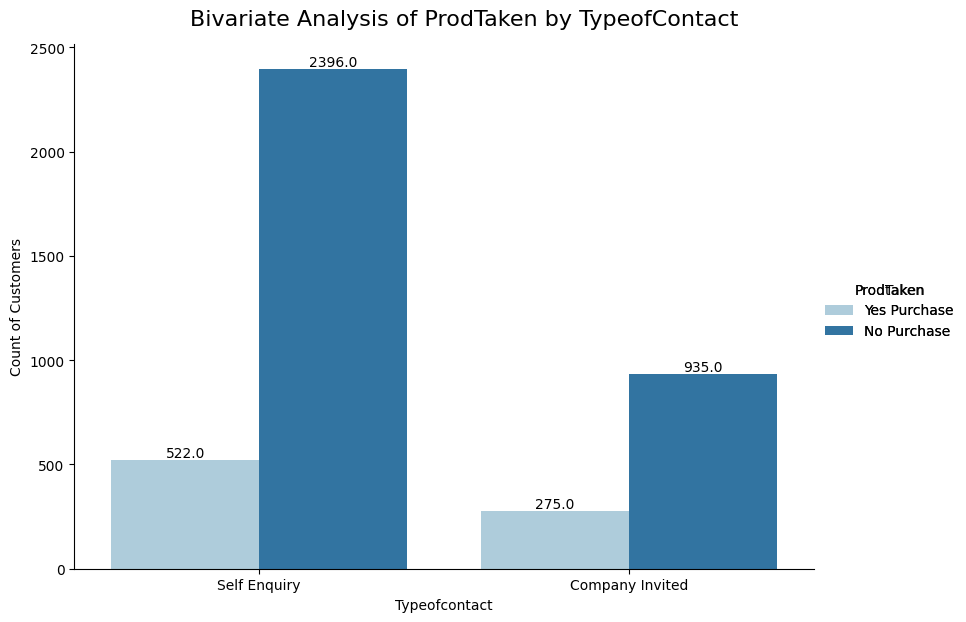

In [ ]:
plot_bivariate_categorical_distribution(
    df=tdf,
    category_col='TypeofContact',
    binary_col='ProdTaken',
    title='Bivariate Analysis of ProdTaken by TypeofContact'
)

**Observation**
* Self Enquiry:
  - This contact type accounts for the vast majority of customer interactions (Total: ~2918 customers).
  - About 522 customers opt for purchasing the product out of ~2918 customers, which contributes only ~17%
* Company Invited:
  - This contact type is significantly less frequent (Total: ~1210 customers).
  - About 275 customers opt for purchasing the product, which contributes only ~22%, which is higher than that of self-enquired customers.
  - This indicates that companies that invite customers have a higher chance of taking the product, even though in both cases, the purchase percentage is very low as per the dataset.
  - For both contact methods, the count of customers who made No Purchase (dark blue bars) is substantially higher than those who made a Yes Purchase

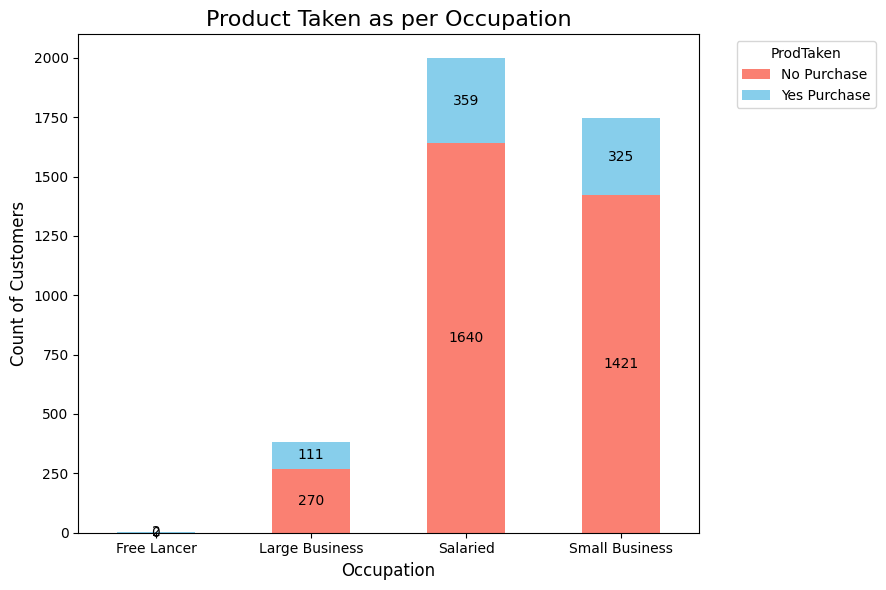

In [ ]:
plot_categorical_distribution(
    df=tdf,
    category_col='Occupation',
    binary_col='ProdTaken',
    title='Product Taken as per Occupation'
)

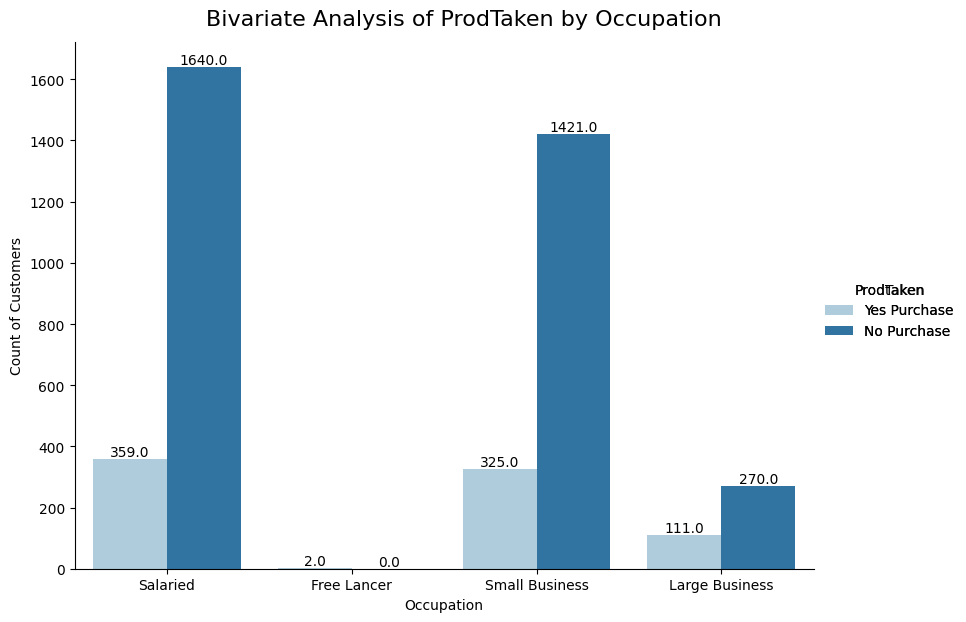

In [ ]:
plot_bivariate_categorical_distribution(
    df=tdf,
    category_col='Occupation',
    binary_col='ProdTaken',
    title='Bivariate Analysis of ProdTaken by Occupation'
)

**Observation**

* Salaried Employees:
  - This group has the highest overall number of customers, with a significant majority choosing not to purchase the product (1640 customers). A smaller but still substantial number (359 customers) made a purchase.
    
* Small Business Owners:
   - This is the second-largest segment of customers. Similar to salaried employees, most did not purchase the product (1421 customers), while 325 customers did purchase it.
     
* Large Business Owners:
  - This group has the fewest customers overall among those who did not purchase the product (270 customers). The number of those who did purchase the product (111 customers) is relatively low in absolute terms.
    
* Free Lancers:
   - This is the smallest customer segment represented in the data. Only 2 free-lancers made a purchase, and none fell into the "No Purchase" category shown in the graph (0 customers).

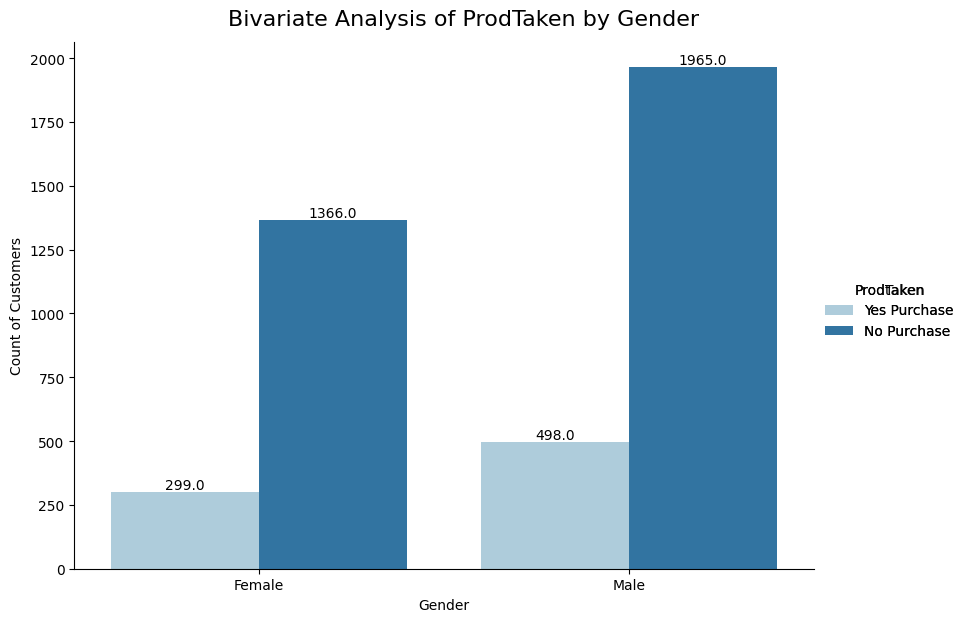

In [ ]:
plot_bivariate_categorical_distribution(
    df=tdf,
    category_col='Gender',
    binary_col='ProdTaken',
    title='Bivariate Analysis of ProdTaken by Gender'
)

**Observation**
* A higher number of males (498) made a purchase compared to females (299).
* A significantly higher number of males (1965) did not make a purchase compared to females (1366).
* In both gender categories, the majority of customers did not purchase the product

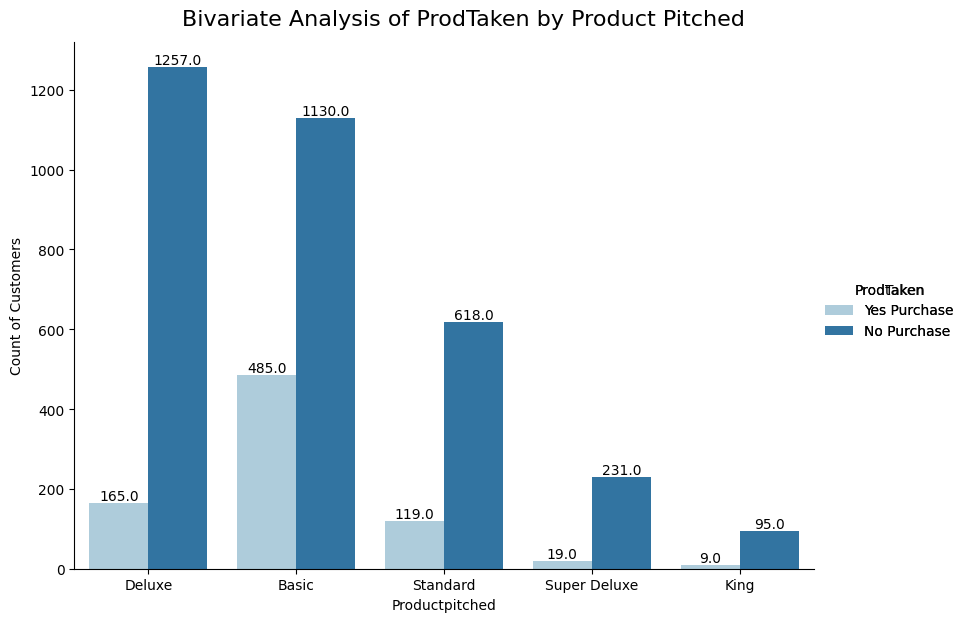

In [ ]:
plot_bivariate_categorical_distribution(
    df=tdf,
    category_col='ProductPitched',
    binary_col='ProdTaken',
    title='Bivariate Analysis of ProdTaken by Product Pitched'
)

**Observation**
* Dominant Non-Purchase Behavior:
  - For every single product pitched, the count of customers who made No Purchase (dark blue bars) is substantially higher than those who made a Yes Purchase (light blue bars).
* Basic Product:
   - The Basic product category has the highest absolute number of "Yes Purchases" (485 customers), suggesting it is the most popular choice among those who do decide to buy.
* Deluxe Product:
  - This is the second-highest purchasing product; however, in this group, the purchase percent is very low compared to the non-purchase case.
     
* Lowest Purchase Counts:
  - The King product resulted in the fewest purchases (9 customers), and the Super Deluxe product also had very few (19 customers).

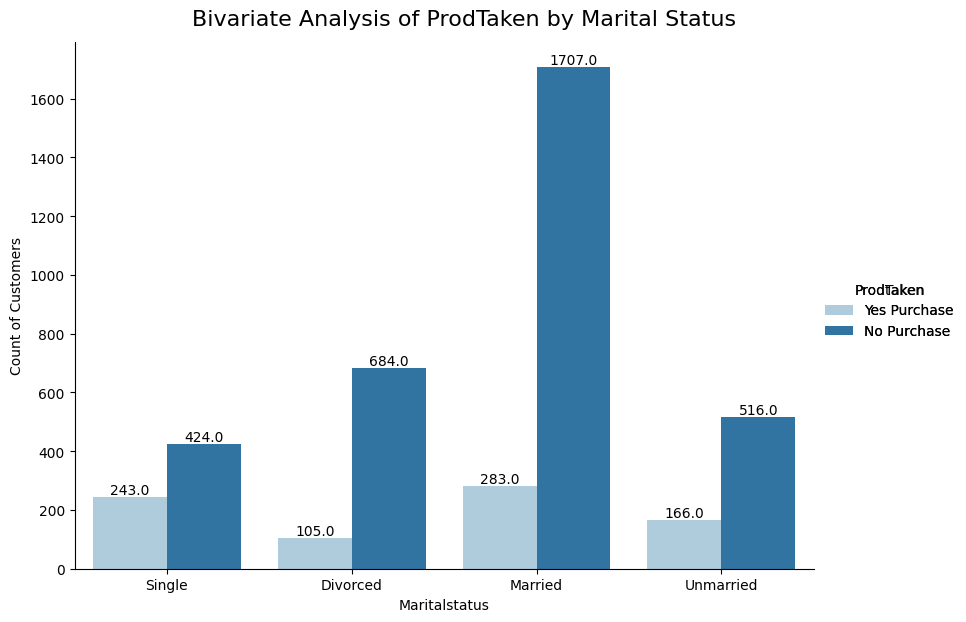

In [ ]:
plot_bivariate_categorical_distribution(
    df=tdf,
    category_col='MaritalStatus',
    binary_col='ProdTaken',
    title='Bivariate Analysis of ProdTaken by Marital Status'
)

**Observation**
* The unmarried customers record a higher product purchase count compared to other groups, despite being fewer in number than married customers.
* The Married Customers have the second-highest purchase count; however, the ratio of purchasers to non-purchasers is quite low.
* The divorced customers exhibit low count as a visitor as well as a purchaser.

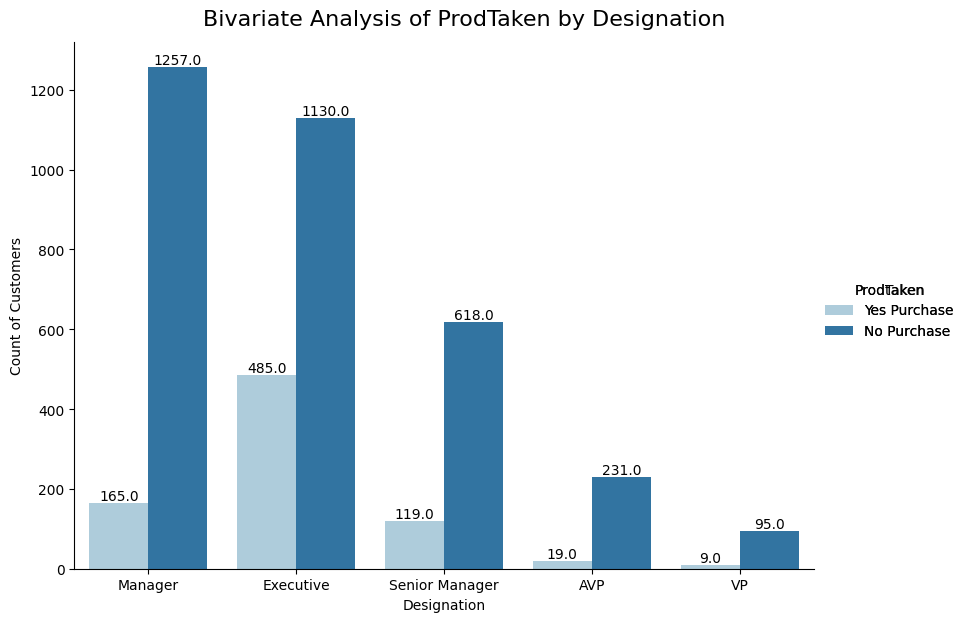

In [ ]:
plot_bivariate_categorical_distribution(
    df=tdf,
    category_col='Designation',
    binary_col='ProdTaken',
    title='Bivariate Analysis of ProdTaken by Designation'
)

**Observation**
* The executives record a higher product purchase count compared to other groups, despite being fewer in number than managers.
* The managers have the second-highest purchase count; however, the ratio of purchasers to non-purchasers is quite low.
* AVP and VP group records very low purchase score, with fewer in count.

## 3.3.MultiVariate Analysis Using HeatMap
### 3.3.1.MultiVariate Analysis of numerical Features

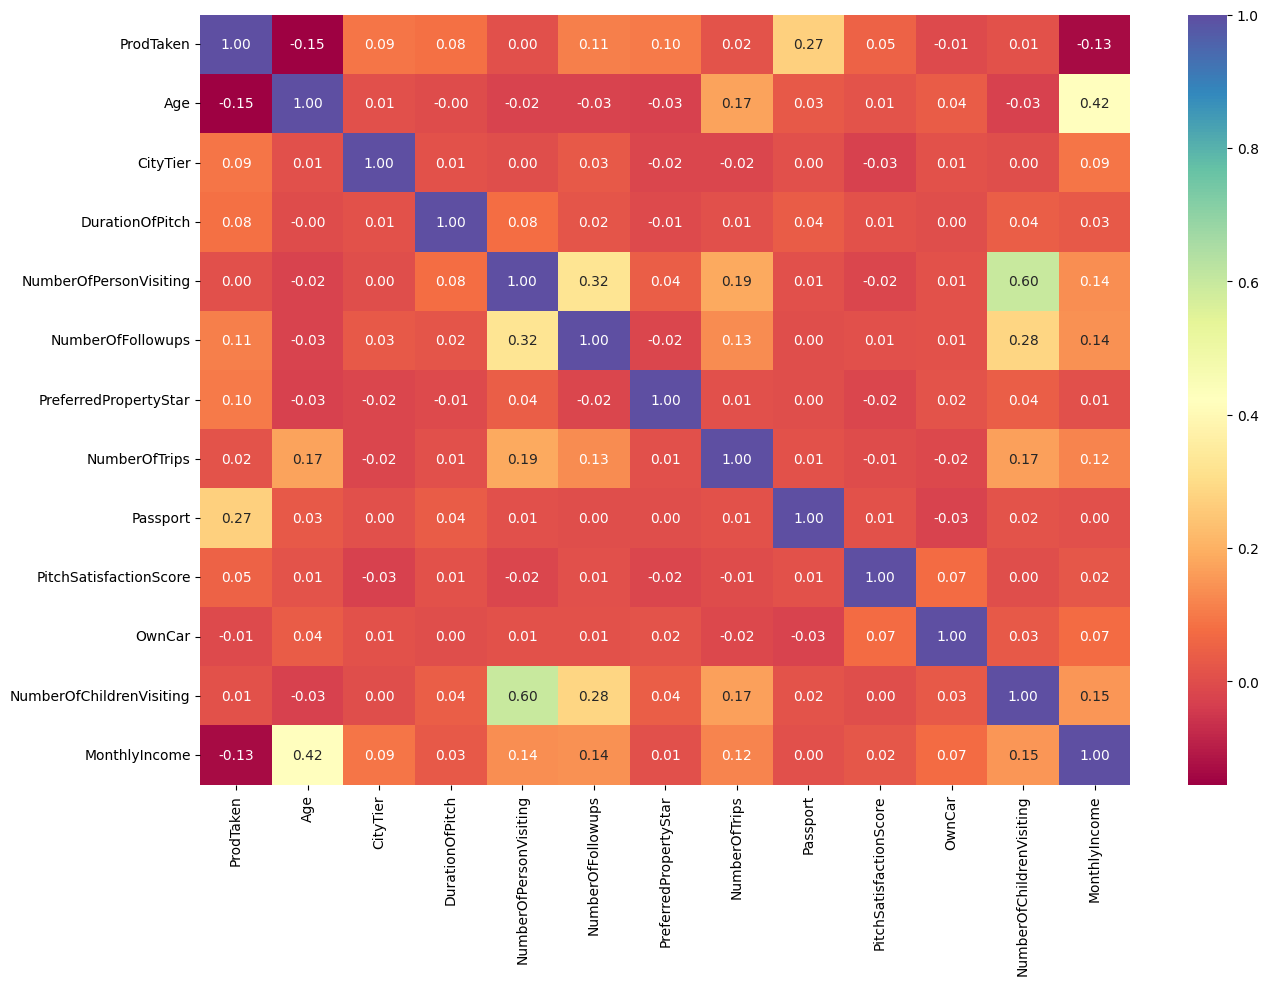

In [ ]:
# defining the size of the plot
plt.figure(figsize=(15, 10))
# plotting the correlation heatmap
sns.heatmap(tdf.corr(numeric_only = True), annot=True, fmt='0.2f', cmap='Spectral');

##

**Observation**  

 * 1.Strong Positive Correlations:

    - NumberOfPersonVisiting has positive corelation with NumberOfChildrenVisiting(60),NumberOfFollowups(32), NumberOfTrips(19), MonthlyIncome(14)
    - NumberOfPersonVisiting and NumberOfChildrenVisiting: As expected, there is a strong positive correlation between the total number of people visiting and the number of children visiting. Larger groups generally contain more children.
    - MonthlyIncome and Age (0.42): Customers' monthly income tends to increase with their age.
    - NumberOfFollowups and NumberOfChildrenVisiting (0.28): There is a moderate positive correlation here, suggesting that customers traveling with more children may require more follow-up interactions.
    - ProdTaken and Passport (0.27): There is a moderate positive link between a customer possessing a passport and them taking a product offered by the company. Customers with passports might be more predisposed to travel packages.
  
* 2.Strong Negative Correlations
    - ProdTaken and Age (-0.15): There is a weak negative correlation, indicating that slightly younger customers are marginally more likely to purchase a product than older customers.

* 3.Multicollinearity Check
  - The feature NumberOfChildrenVisiting have a strong positive correlation of 0.60 with NumberOfPersonVisiting and  correlatoion of 28 with NumberOfFollowups, indicating a potential multicollinearity alongwith very less impact (0.1) on Target feature,which can affect model building.
  - As NumberOfPersonVisiting is more important compared to NumberOfChildrenVisiting, So dropping NumberOfChildrenVisiting column may be a good approach to treat the multicollinearity.
  - MonthlyIncome and Age, being continuous values along with high correlation, can impact model performance. Therefore dropping both of the feature and performing feature engineering can be recommended.
    
* 4.Very Weak Features
  -The below features show zero to near-zero correlation with ProdTaken and do not appear impactful:
    - PreferredPropertyStar: Though it has positive corelation with ProdTaken, it is not part of initial visit of customer and can create noise.
    - OwnCar (0.01 → noise)    
    - NumberOfChildrenVisiting (0.01 → noise)    
    - NumberOfTrips (0.02 → borderline)
    - DurationOfPitch (0.08)

### 3.3.2. Heatmap for Categorical Columns after encoding

In [ ]:
df = tdf.copy()
df_encoded = pd.get_dummies(df, columns=cat_col, drop_first=True)
df_encoded.head(5)

,ProdTaken,Age,CityTier,DurationOfPitch,NumberOfPersonVisiting,NumberOfFollowups,PreferredPropertyStar,NumberOfTrips,Passport,PitchSatisfactionScore,...,ProductPitched_King,ProductPitched_Standard,ProductPitched_Super Deluxe,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Unmarried,Designation_Executive,Designation_Manager,Designation_Senior Manager,Designation_VP
0,1,41,3,6,3,3,3,1,1,2,...,False,False,False,False,True,False,False,True,False,False
1,0,49,1,14,3,4,4,2,0,3,...,False,False,False,False,False,False,False,True,False,False
2,1,37,1,8,3,4,3,7,1,3,...,False,False,False,False,True,False,True,False,False,False
3,0,33,1,9,2,3,3,2,1,5,...,False,False,False,False,False,False,True,False,False,False
4,0,32,1,8,3,3,3,1,0,5,...,False,False,False,False,True,False,True,False,False,False


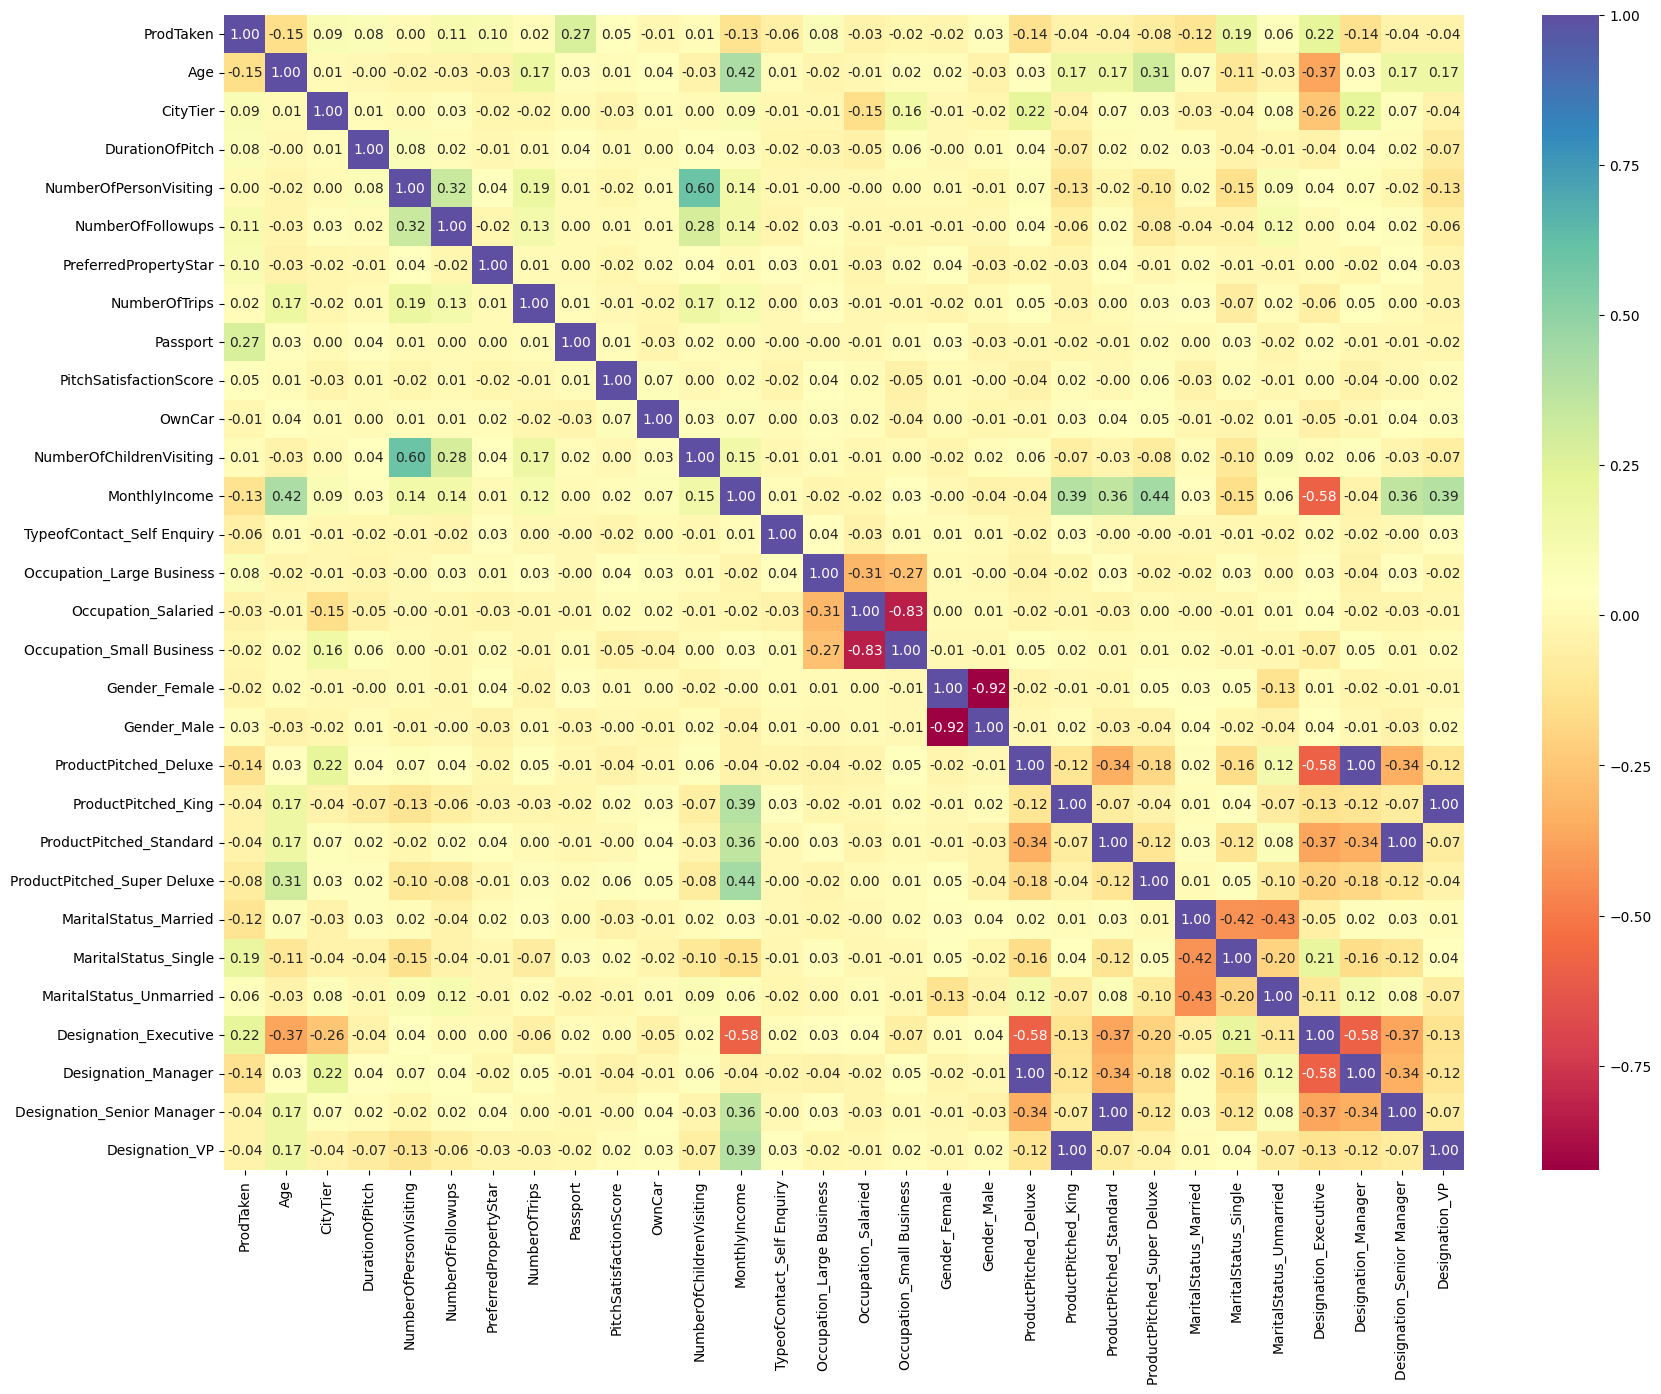

In [ ]:
# defining the size of the plot
plt.figure(figsize=(20, 15))
# plotting the correlation heatmap
sns.heatmap(df_encoded.corr(numeric_only = True), annot=True, fmt='0.2f', cmap='Spectral');

**Observation**
* 1.Strong Positive Correlations:
  - Designation: Various designations  show a positive correlation with target feature.
  - MaritalStatus: This feature has a good correlation, specifically single/unmarried  group has higher chances of purchase compared to others
* 2.Weak Positive Correlations:
  - Gender: This feature has very low collinearity with ProdTaken. Usually gender does not strongly influence decisions like whether to take a travel package. Therefore can be removed to build model.
  - TypeofContact & Occupation: These features show very low correlation with target feature; however, they impact the decision indirectly

# 4. Data Registration

## 4.1. Create project folders

In [ ]:
# Create a master folder for our project named TourismPackagePrediction
# Create data subfolder under master folder to keep dataset
os.makedirs("TourismPackagePrediction/data", exist_ok=True)

#Once the data folder created after executing the above cell,  the tourism.csv is uploaded to the folder

# Create modelbuilding subfolder under master folder to keep model building files
os.makedirs("TourismPackagePrediction/modelbuilding", exist_ok=True)

## 4.2. Create code file to upload dateset to huggingface dataset repo

In [ ]:
%%writefile TourismPackagePrediction/modelbuilding/data_register.py

# Import necessary libraries
from huggingface_hub.utils import RepositoryNotFoundError, HfHubHTTPError
from huggingface_hub import HfApi, create_repo
import os

# Define Huggingface Repo Name and RepoType
repo_id = "supravab/Tourism_Package_Prediction"
repo_type = "dataset"

# Initialize API client using huggingface token from git secret
api = HfApi(token=os.getenv("HF_TOKEN"))

# Step 1: Check if the space exists orelse create new space
try:
    api.repo_info(repo_id=repo_id, repo_type=repo_type)
    print(f"Space '{repo_id}' already exists. Using it.")
except RepositoryNotFoundError:
    print(f"Space '{repo_id}' not found. Creating new space...")
    create_repo(repo_id=repo_id, repo_type=repo_type, private=False)
    print(f"Space '{repo_id}' created.")

# Upload data file to huggingface space
try:
    api.upload_folder(
        folder_path="TourismPackagePrediction/data",
        repo_id=repo_id,
        repo_type=repo_type,
    )
except Exception as e:
    print(f"Error uploading dataset:{e}")

## Feature Engineering to Reduce Multicolinearity and Improve generalization

In [ ]:
# -----------------------------
# 1. FEATURE ENGINEERING
# -----------------------------

# 1. Create HasChildren Column based on NumberOfChildrenVisiting
tdf['HasChildren'] = (tdf['NumberOfChildrenVisiting'] > 0).astype(int)
print(tdf['HasChildren'].value_counts(normalize=True))


# 2. Create HasChildren Column AgeGroup based on Age
def AgeGroup(row):
    age = row['Age']
    if age <= 18:
        return 'Young'
    elif age >= 19 and age <= 40:
        return 'Adult'
    else:
        return 'Old'

tdf['AgeGroup'] = tdf.apply(AgeGroup, axis=1)
print(tdf['AgeGroup'].value_counts(normalize=True))


# 3. Monthly Income Categorization — Low, Mid, High
def IncomeCategory(row):
    income = row['MonthlyIncome']
    if income < 20000:
        return 'Low'
    elif income >= 20000 and income <= 30000:
        return 'Mid'
    else:
        return 'High'

tdf['IncomeCategory'] = tdf.apply(IncomeCategory, axis=1)
print(tdf['IncomeCategory'].value_counts(normalize=True))


# 4. Categorize DurationOfPitch — Short, Long, High
def PitchPeriodCategory(row):
    pitch = row['DurationOfPitch']
    if pitch <= 10:
        return 'Short'
    elif pitch >= 11 and pitch <= 30:
        return 'Long'
    else:
        return 'High'

tdf['PitchPeriodCategory'] = tdf.apply(PitchPeriodCategory, axis=1)
print(tdf['PitchPeriodCategory'].value_counts(normalize=True))

HasChildren
1    0.794331
0    0.205669
Name: proportion, dtype: float64
AgeGroup
Adult    0.673207
Old      0.323401
Young    0.003391
Name: proportion, dtype: float64
IncomeCategory
Mid     0.729651
Low     0.183624
High    0.086725
Name: proportion, dtype: float64
PitchPeriodCategory
Long     0.556444
Short    0.360707
High     0.082849
Name: proportion, dtype: float64


### Drop Columns after Feature Engineering

In [ ]:
# Create a copy of the dataframe
drptdf = tdf.copy()
# Drop the unique identifier
columns_to_drop = ['OwnCar','Age', 'NumberOfChildrenVisiting','Gender','MonthlyIncome','DurationOfPitch','PreferredPropertyStar']
# Check which columns actually exist before dropping to avoid errors
existing_columns_to_drop = [col for col in columns_to_drop if col in drptdf.columns]
if existing_columns_to_drop:
    drptdf = drptdf.drop(columns=existing_columns_to_drop)
print(drptdf.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4128 entries, 0 to 4127
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   ProdTaken               4128 non-null   int64 
 1   TypeofContact           4128 non-null   object
 2   CityTier                4128 non-null   int64 
 3   Occupation              4128 non-null   object
 4   NumberOfPersonVisiting  4128 non-null   int64 
 5   NumberOfFollowups       4128 non-null   int64 
 6   ProductPitched          4128 non-null   object
 7   MaritalStatus           4128 non-null   object
 8   NumberOfTrips           4128 non-null   int64 
 9   Passport                4128 non-null   int64 
 10  PitchSatisfactionScore  4128 non-null   int64 
 11  Designation             4128 non-null   object
 12  HasChildren             4128 non-null   int64 
 13  AgeGroup                4128 non-null   object
 14  IncomeCategory          4128 non-null   object
 15  Pitc

### Encode Categorical Features

In [ ]:
encodeddf = tdf.copy()
drp_cat_cols = encodeddf.select_dtypes(include=['object', 'category']).columns
encodeddf = pd.get_dummies(encodeddf, columns=drp_cat_cols, drop_first=True)
print(encodeddf.info())
print(encodeddf.head(5))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4128 entries, 0 to 4127
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   ProdTaken                    4128 non-null   int64
 1   Age                          4128 non-null   int64
 2   CityTier                     4128 non-null   int64
 3   DurationOfPitch              4128 non-null   int64
 4   NumberOfPersonVisiting       4128 non-null   int64
 5   NumberOfFollowups            4128 non-null   int64
 6   PreferredPropertyStar        4128 non-null   int64
 7   NumberOfTrips                4128 non-null   int64
 8   Passport                     4128 non-null   int64
 9   PitchSatisfactionScore       4128 non-null   int64
 10  OwnCar                       4128 non-null   int64
 11  NumberOfChildrenVisiting     4128 non-null   int64
 12  MonthlyIncome                4128 non-null   int64
 13  HasChildren                  4128 non-null   int

## Prepare Data

In [ ]:
# Import necessary libraries
import sklearn
from sklearn.model_selection import train_test_split

# Set Target variable
target = "ProdTaken"
X = tdf.drop(columns=[target])
y = tdf[target].astype(int)

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

# -------------------------------------------------------------------------
# 2. PREPROCESSING PIPELINE
# -------------------------------------------------------------------------
numeric_features = X_train.select_dtypes(include=[np.number]).columns
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns

# Model Building

In [ ]:
# Import necessary libraries
import sklearn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

import xgboost as xgb
import catboost as cgb
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_auc_score
)

# To undersample and oversample the data
import imblearn
from imblearn.over_sampling import SMOTE

# Note: The scikit-learn library is imported as 'sklearn'
print(f"scikit-learn version: {sklearn.__version__}")
print(f"xgboost version: {xgb.__version__}")
print(f"catboost version: {cgb.__version__}")
# Note: The imbalanced-learn library is imported as 'imblearn'
print(f"imbalanced-learn version: {imblearn.__version__}")

#print(f"requests version: {requests.__version__}")
#print(f"huggingface_hub version: {huggingface_hub.__version__}")
#print(f"joblib version: {joblib.__version__}")

scikit-learn version: 1.6.1
xgboost version: 3.1.2
catboost version: 1.2.8
imbalanced-learn version: 0.14.0


### Function to provide metric scores(accuracy,recall and precision) on train and test set

In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score
    roc_auc = roc_auc_score(target, pred) # Calculate ROC AUC score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {
            "Accuracy": acc,
            "Recall": recall,
            "Precision": precision,
            "F1": f1,
            "ROC_AUC": roc_auc
        },
        index=[0],
    )

    return df_perf

# Base Model Creation without using pipeline

In [ ]:
## for initial test
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    AdaBoostClassifier,
    GradientBoostingClassifier,
    RandomForestClassifier,
    BaggingClassifier,
)
# Calculate scale_pos_weight
from collections import Counter

# Set Target variable
target = "ProdTaken"
df= encodeddf.copy()
P = df.drop(columns=[target])
q = df[target].astype(int)

# Split Dataset
P_train, P_test, q_train, q_test = train_test_split(
    P, q, test_size=0.25, stratify=y, random_state=42
)

counter = Counter(q_train)
scale = counter[0] / counter[1]

random_forest_model = RandomForestClassifier(random_state=1, class_weight='balanced')
bagging_with_logreg_model = BaggingClassifier(estimator=LogisticRegression(class_weight='balanced'), random_state=1)
bagging_with_dtree_model = BaggingClassifier(estimator=DecisionTreeClassifier(class_weight='balanced'), random_state=1)
adaboost_with_logreg_model = AdaBoostClassifier(estimator=LogisticRegression(class_weight='balanced'), random_state=1)
adaboost_with_dtree_model = AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight='balanced'), random_state=1)
gradientboost_model = GradientBoostingClassifier(random_state=1)
xgboost_model = XGBClassifier(random_state=1, eval_metric="logloss", scale_pos_weight=scale)

models = []  # Empty list to store all the models

# Appending models into the list
models.append(("Random forest",random_forest_model))
models.append(("Bagging With LogisticReg", bagging_with_logreg_model))
models.append(("Bagging With Decisiontree", bagging_with_dtree_model))
models.append(("Adaboost With LogisticReg", adaboost_with_logreg_model))
models.append(("Adaboost With Decisiontree", adaboost_with_dtree_model))
models.append(("GBM", gradientboost_model))
models.append(("Xgboost", xgboost_model))

In [ ]:
# training performance comparison
model_train_perfs = []  # Empty list to store all the models training performance metrics
for name, model in models:
   model.fit(P_train, q_train)
   model_perf_metric = model_performance_classification_sklearn(model, P_train, q_train)
   model_train_perfs.append(model_perf_metric.T)

models_train_comp_df = pd.concat(model_train_perfs, axis=1,)
models_train_comp_df.columns = [
    "Balanced Random Forest",
    "Bagging With LogisticReg",
    "Bagging With Decisiontree",
    "Adaboost With LogisticReg",
    "Adaboost With Decisiontree",
    "GradientBoosting",
    "XGBoosting"]
print("Training performance comparison:")
print(models_train_comp_df.T)

Training performance comparison:
                            Accuracy    Recall  Precision        F1   ROC_AUC
Balanced Random Forest      1.000000  1.000000   1.000000  1.000000  1.000000
Bagging With LogisticReg    0.703488  0.727425   0.365546  0.486577  0.712591
Bagging With Decisiontree   0.994509  0.971572   1.000000  0.985581  0.985786
Adaboost With LogisticReg   0.684109  0.625418   0.331560  0.433372  0.661788
Adaboost With Decisiontree  1.000000  1.000000   1.000000  1.000000  1.000000
GradientBoosting            0.894380  0.528428   0.875346  0.659020  0.755207
XGBoosting                  1.000000  1.000000   1.000000  1.000000  1.000000


In [ ]:
# testing performance comparison
model_test_perfs = []  # Empty list to store all the models testing performance metrics
for name, model in models:
   model.fit(P_train, q_train)
   model_perf_metrics = model_performance_classification_sklearn(model, P_test, q_test)
   model_test_perfs.append(model_perf_metrics.T)
models_test_comp_df = pd.concat(model_test_perfs, axis=1,)
models_test_comp_df.columns = [
    "Balanced Random Forest",
    "Bagging With LogisticReg",
    "Bagging With Decisiontree",
    "Adaboost With LogisticReg",
    "Adaboost With Decisiontree",
    "GradientBoosting",
    "XGBoosting"]
print("Testing performance comparison:")
print(models_test_comp_df.T)

Testing performance comparison:
                            Accuracy    Recall  Precision        F1   ROC_AUC
Balanced Random Forest      0.907946  0.582915   0.906250  0.709480  0.784254
Bagging With LogisticReg    0.731589  0.738693   0.395161  0.514886  0.734293
Bagging With Decisiontree   0.902132  0.572864   0.876923  0.693009  0.776828
Adaboost With LogisticReg   0.704457  0.683417   0.359788  0.471404  0.696450
Adaboost With Decisiontree  0.909884  0.798995   0.750000  0.773723  0.867685
GradientBoosting            0.868217  0.437186   0.783784  0.561290  0.704187
XGBoosting                  0.942829  0.854271   0.850000  0.852130  0.909128


# Model Training with MLFlow

In [ ]:
!pip install mlflow==3.0.1 pyngrok==7.2.12 -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.0/40.0 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 107.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 95.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.0/85.0 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 753.9/753.9 kB 57.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 20.8 MB/s eta 0:00:00


In [ ]:
import mlflow
import sklearn
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from collections import Counter

preprocessor = make_column_transformer(
    (StandardScaler(), numeric_features),
    (SimpleImputer(strategy="median"), numeric_features),
    (OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_features)
    #(RF, XGBoost, LightGBM)
    #👉 Keep drop='first' = False (default), because trees don't suffer from multicollinearity.
    #(SimpleImputer(strategy="most_frequent"), categorical_features),
)

# Calculate scale_pos_weight
counter1 = Counter(y_train)
scale1 = counter1[0] / counter1[1]
# Set the clas weight to handle class imbalance
#class_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
#xgbmodelv1=xgb.XGBClassifier(scale_pos_weight=class_weight,random_state=42)
xgbmodel= XGBClassifier(random_state=1, eval_metric="logloss", scale_pos_weight=scale1)

# -------------------------------------------------------------------------
# 3. MODEL DEFINITIONS + PARAM GRIDS
# -------------------------------------------------------------------------
model_configs = {
    "random_forest_balanced": {
        "model": RandomForestClassifier(
            class_weight="balanced",
            random_state=42
        ),
        "params": {}
    },
    "xgboost": {
        "model": xgbmodel,
        "params": {}
    },
    "catboost": {
        "model": CatBoostClassifier(
            iterations=300,
            depth=6,
            learning_rate=0.05,
            verbose=0
        ),
        "params": {}
    }
}

# -------------------------------------------------------------------------
# 4. TRAIN, EVALUATE & LOG MODELS IN MLFLOW
# -------------------------------------------------------------------------
mlflow.set_experiment("tourism_customer_prediction")

results = []
best_model = None
best_score = -np.inf

model_train_perfs = []
model_test_perfs = []
model_params = {}

for model_name, cfg in model_configs.items():

    with mlflow.start_run(run_name=model_name):

        '''
        # Create pipeline: Preprocess → SMOTE → Model
        clf = ImbPipeline(steps=[
            ('preprocess', preprocess),
            ('smote', SMOTE(random_state=42)),
            ('model', cfg['model'])
        ])
        '''

        # Create pipeline: Preprocess → SMOTE → Model
        clf = make_pipeline(
            preprocessor,
            cfg["model"]
        )

        # Train
        clf.fit(X_train, y_train)

        # Predict
        y_pred = clf.predict(X_test)
        y_proba = clf.predict_proba(X_test)[:, 1]

        # Metrics
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_proba)

        # Log metrics
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("f1_score", f1)
        mlflow.log_metric("precision", precision)
        mlflow.log_metric("recall", recall)
        mlflow.log_metric("roc_auc", roc_auc)

        # Log parameters
        for p, v in cfg["params"].items():
            mlflow.log_param(p, v)

        # Log entire model
        mlflow.sklearn.log_model(clf, model_name)

        results.append({
            "model": model_name,
            "accuracy": acc,
            "f1": f1,
            "precision": precision,
            "recall": recall,
            "roc_auc": roc_auc
        })

        # Track best model
        if f1 > best_score:
            best_score = f1
            best_model = (model_name, clf)
            mlflow.set_tag("best_model", model_name)
            #model_params = cfg["params"].copy()
            model_params.update(cfg["params"])

# -------------------------------------------------------------------------
# 5. PRINT BEST MODEL
# -------------------------------------------------------------------------
print("\n=== MODEL PERFORMANCE SUMMARY ===")
df_results = pd.DataFrame(results)
print(df_results)

print("\n🔥 BEST MODEL SELECTED:", best_model[0])
print("🔥 BEST PARAMS:", model_params)
print("🔥 BEST F1 SCORE:", best_score)

2025/12/05 15:15:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/12/05 15:15:10 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2025/12/05 15:15:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/12/05 15:15:13 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.
2025/12/05 15:15:14 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2025/12/05 15:15:17 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.



=== MODEL PERFORMANCE SUMMARY ===
                    model  accuracy        f1  precision    recall   roc_auc
0  random_forest_balanced  0.911822  0.723404   0.915385  0.597990  0.972923
1                 xgboost  0.933140  0.825316   0.831633  0.819095  0.965928
2                catboost  0.913760  0.740525   0.881944  0.638191  0.958013

🔥 BEST MODEL SELECTED: xgboost
🔥 BEST PARAMS: {}
🔥 BEST F1 SCORE: 0.8253164556962025


**Observation**
* XGBoost gives the best F1 (0.82) and the best balance of precision and recall, compared to other models.
* Logistic regression performs the worst.
* In classification tasks with class imbalance, the F1 score is the most reliable metric, so XGBoost is the right model choice.

### Apply SMOTE(Synthetic Minority Oversampling Technique)  and RandomizedSearchCV Tuning

In [ ]:
from sklearn.model_selection import GridSearchCV,StratifiedKFold
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import make_pipeline

print("Before Oversampling, ProdTaken: {}".format(y_train.value_counts()))

# Apply SMOTE to training data only
sm = SMOTE(random_state=42)
X_train_oversampled, y_train_oversampled = sm.fit_resample(X_train, y_train)

print("Before Oversampling, ProdTaken: {}".format(y_train_oversampled.value_counts()))

Before Oversampling, ProdTaken: ProdTaken
0    2498
1     598
Name: count, dtype: int64
Before Oversampling, ProdTaken: ProdTaken
1    2498
0    2498
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# ===========================
# 1. XGBoost Model
# ===========================
tunedxgb_rscv = XGBClassifier(
    objective="binary:logistic",
    random_state=42,
    tree_method="hist",
    eval_metric="logloss"
)

# ===========================
# 2. Parameter Search Space
# ===========================
param_rscv = {
    'xgbclassifier__n_estimators': [200, 300, 400],
    'xgbclassifier__learning_rate': [0.01, 0.05, 0.1],
    'xgbclassifier__max_depth': [3, 4, 5],
    'xgbclassifier__min_child_weight': [3, 5, 7],
    'xgbclassifier__gamma': [0, 0.1, 0.2],
    'xgbclassifier__subsample': [0.7, 0.8, 0.9],
    'xgbclassifier__colsample_bytree': [0.6, 0.7, 0.8],
    'xgbclassifier__reg_lambda': [0.5, 1.0, 1.5],
    'xgbclassifier__reg_alpha': [0.1, 0.3, 0.5]
}

# ===========================
# 3. Pipeline (Preprocessor + SMOTE + XGB)
# ===========================
pipe_rscv = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('xgbclassifier', tunedxgb_rscv)
])

# ===========================
# 4. MLflow Experiment
# ===========================
results = []
best_tuned_rscvmodel = None
best_tuned__rscvscore = -np.inf
model_params_rscv = {}

mlflow.set_experiment("xgb_rscv_f1_optimization")

with mlflow.start_run():

    # Randomized Search CV
    search = RandomizedSearchCV(
        estimator=pipe_rscv,
        param_distributions=param_rscv,
        scoring='f1',
        cv=5,
        n_iter=40,
        verbose=2,
        n_jobs=1,
        random_state=42
    )
    search.fit(X_train_oversampled, y_train_oversampled)

    best_tuned_rscvmodel = search.best_estimator_

    mlflow.log_params(search.best_params_)
    print("\n=== BEST PARAMETERS ===")
    print(search.best_params_)

    # ===========================
    # 5. Tune the Classification Threshold
    # ===========================
    # Calculate probabilities on the ORIGINAL training data for threshold tuning
    y_prob1 = best_tuned_rscvmodel.predict_proba(X_train)[:, 1]

    best_thr = 0.5
    best_f1 = 0

    for thr in np.arange(0.2, 0.8, 0.01):
        y_pred_thr = (y_prob1 >= thr).astype(int)
        # Compare with ORIGINAL y_train for threshold tuning
        score = f1_score(y_train, y_pred_thr)
        if score > best_f1:
            best_thr = thr
            best_f1 = score

    print(f"\nBest Threshold: {best_thr}")
    print(f"Best F1 Score at Threshold: {best_f1}")

    mlflow.log_metric("best_threshold", best_thr)
    mlflow.log_metric("best_threshold_f1", best_f1)

    # ===========================
    # 6. Evaluate Tuned Model
    # ===========================
    # Evaluate on ORIGINAL training data after threshold tuning
    y_pred_train_proba1 = best_tuned_rscvmodel.predict_proba(X_train)[:, 1]
    y_pred_train1 = (y_pred_train_proba1 >= best_thr).astype(int)

    # Evaluate on test data
    y_pred_test_proba1 = best_tuned_rscvmodel.predict_proba(X_test)[:, 1]
    y_pred_test1 = (y_pred_test_proba1 >= best_thr).astype(int)

    # Use ORIGINAL y_train for training report
    train_report1 = classification_report(y_train, y_pred_train1, output_dict=True)
    test_report1 = classification_report(y_test, y_pred_test1, output_dict=True)

    metrics1 = {
    "train_accuracy": train_report1['accuracy'],
    "train_precision": train_report1['1']['precision'],
    "train_recall": train_report1['1']['recall'],
    "train_f1-score": train_report1['1']['f1-score'],
    "test_accuracy": test_report1['accuracy'],
    "test_precision": test_report1['1']['precision'],
    "test_recall": test_report1['1']['recall'],
    "test_f1-score": test_report1['1']['f1-score']
    }
    # print best tuning model scores
    print("=== LOGGED METRICS TO MLFLOW ===")
    for k, v in metrics1.items():
        print(f"{k}: {v}")

    mlflow.log_metrics(metrics1)

Fitting 5 folds for each of 40 candidates, totalling 200 fits
[CV] END xgbclassifier__colsample_bytree=0.8, xgbclassifier__gamma=0.2, xgbclassifier__learning_rate=0.05, xgbclassifier__max_depth=5, xgbclassifier__min_child_weight=5, xgbclassifier__n_estimators=200, xgbclassifier__reg_alpha=0.3, xgbclassifier__reg_lambda=1.5, xgbclassifier__scale_pos_weight=3, xgbclassifier__subsample=0.8; total time=   0.2s
[CV] END xgbclassifier__colsample_bytree=0.8, xgbclassifier__gamma=0.2, xgbclassifier__learning_rate=0.05, xgbclassifier__max_depth=5, xgbclassifier__min_child_weight=5, xgbclassifier__n_estimators=200, xgbclassifier__reg_alpha=0.3, xgbclassifier__reg_lambda=1.5, xgbclassifier__scale_pos_weight=3, xgbclassifier__subsample=0.8; total time=   0.2s
[CV] END xgbclassifier__colsample_bytree=0.8, xgbclassifier__gamma=0.2, xgbclassifier__learning_rate=0.05, xgbclassifier__max_depth=5, xgbclassifier__min_child_weight=5, xgbclassifier__n_estimators=200, xgbclassifier__reg_alpha=0.3, xgbclassi

In [ ]:
from imblearn.under_sampling import TomekLinks

tl = TomekLinks()

X_train_clean, y_train_clean = tl.fit_resample(X_train, y_train)
print("After TomekLinks:", X_train_clean.shape)

# Set the clas weight to handle class imbalance
# Calculate scale_pos_weight
counter2 = Counter(y_train_clean)
scale2 = counter2[0] / counter2[1]
#class_weight1 = y_train_clean.value_counts()[0] / y_train_clean.value_counts()[1]

xgb_rsv_undersample = XGBClassifier(
    #objective="binary:logistic",
    random_state=1,
    eval_metric="logloss",
    scale_pos_weight=scale2,
    #n_estimators=1000,               # high num -> early stopping will trim
    #verbosity=0,
)
#xgbmodel= XGBClassifier(random_state=1, eval_metric="logloss", scale_pos_weight=scale1)

# ==========================================
# 4. PARAMETER SEARCH SPACE (balanced)
# ==========================================
param_rsv = {
    'xgbclassifier__n_estimators': [50, 75, 100],    # number of tree to build
    'xgbclassifier__max_depth': [2, 3],    # maximum depth of each tree
    'xgbclassifier__colsample_bytree': [0.4, 0.6],    # percentage of attributes to be considered (randomly) for each tree
    'xgbclassifier__colsample_bylevel': [0.4, 0.6],    # percentage of attributes to be considered (randomly) for each level of a tree
    'xgbclassifier__learning_rate': [0.01, 0.1],    # learning rate
    'xgbclassifier__reg_lambda': [0.4, 0.6],    # L2 regularization factor
}

# ==========================================
# 5. Pipeline
# ==========================================
cat_cols_clean = X_train_clean.select_dtypes(include=['object', 'category']).columns

tuned_preprocessor = make_column_transformer(
    (StandardScaler(), numeric_features),
    (SimpleImputer(strategy="median"), numeric_features),
    (OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols_clean)
    #(RF, XGBoost, LightGBM)
    #👉 Keep drop='first' = False (default), because trees don't suffer from multicollinearity.
    #(SimpleImputer(strategy="most_frequent"), categorical_features),
)
pipe_rsv = Pipeline([
    ('preprocessor', tuned_preprocessor),
    ('xgbclassifier', xgb_rsv_undersample)
])

# ===========================
# 4. MLflow Experiment
# ===========================
results = []
best_tuned_rsvmodel = None
best_tuned__rsvscore = -np.inf
model_params_rsv = {}

mlflow.set_experiment("xgb_rsv_f1_optimization")

with mlflow.start_run():

    searchcv = RandomizedSearchCV(
        estimator=pipe_rsv,
        param_distributions=param_rsv,
        scoring="f1",
        n_iter=40,
        cv=5,
        verbose=2,
        random_state=42,
        n_jobs=1,
    )

    searchcv.fit(X_train_clean, y_train_clean)

    best_tuned_rsvmodel = searchcv.best_estimator_

    mlflow.log_params(searchcv.best_params_)
    print("\n=== BEST PARAMETERS ===")
    print(searchcv.best_params_)

    # ===========================
    # 5. Tune the Classification Threshold
    # ===========================
    # Calculate probabilities on the ORIGINAL training data for threshold tuning
    y_prob1 = best_tuned_rsvmodel.predict_proba(X_train_clean)[:, 1]

    best_thr = 0.5
    best_f1 = 0

    for thr in np.arange(0.2, 0.8, 0.01):
        y_pred_thr = (y_prob1 >= thr).astype(int)
        # Compare with ORIGINAL y_train for threshold tuning
        score = f1_score(y_train_clean, y_pred_thr)
        if score > best_f1:
            best_thr = thr
            best_f1 = score

    print(f"\nBest Threshold: {best_thr}")
    print(f"Best F1 Score at Threshold: {best_f1}")

    mlflow.log_metric("best_threshold", best_thr)
    mlflow.log_metric("best_threshold_f1", best_f1)

    # ===========================
    # 6. Evaluate Tuned Model
    # ===========================
    # Evaluate on ORIGINAL training data after threshold tuning
    y_pred_train_proba1 = best_tuned_rsvmodel.predict_proba(X_train_clean)[:, 1]
    y_pred_train1 = (y_pred_train_proba1 >= best_thr).astype(int)

    # Evaluate on test data
    y_pred_test_proba1 = best_tuned_rsvmodel.predict_proba(X_test)[:, 1]
    y_pred_test1 = (y_pred_test_proba1 >= best_thr).astype(int)

    # Use ORIGINAL y_train for training report
    train_report1 = classification_report(y_train_clean, y_pred_train1, output_dict=True)
    test_report1 = classification_report(y_test, y_pred_test1, output_dict=True)

    metrics1 = {
    "train_accuracy": train_report1['accuracy'],
    "train_precision": train_report1['1']['precision'],
    "train_recall": train_report1['1']['recall'],
    "train_f1-score": train_report1['1']['f1-score'],
    "test_accuracy": test_report1['accuracy'],
    "test_precision": test_report1['1']['precision'],
    "test_recall": test_report1['1']['recall'],
    "test_f1-score": test_report1['1']['f1-score']
    }
    # print best tuning model scores
    print("=== LOGGED METRICS TO MLFLOW ===")
    for k, v in metrics1.items():
        print(f"{k}: {v}")

    mlflow.log_metrics(metrics1)

ValueError: could not convert string to float: 'Self Enquiry'

## Data Preparation

In [ ]:
%%writefile tourism_project/model_building/prep.py

# Import necessary libraries
# for data manipulation
import pandas as pd
import sklearn
# for creating a folder
import os
# for data preprocessing and pipeline creation
from sklearn.model_selection import train_test_split
# for converting text data in to numerical representation
from sklearn.preprocessing import LabelEncoder
# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi


# Connect to HuggingFace Space using token from git secret
try:
    api = HfApi(token=os.getenv("HF_TOKEN"))
except Exception as e:
    print(f"Error connecting to HuggingFace Space:{e}")


# Retrieve dataset from HuggingFace Space
try:
    DATASET_PATH = "hf://datasets/supravab/Tourism-Package-Prediction-MLOps/tourism.csv"
    tourismdf = pd.read_csv(DATASET_PATH)
    print("Dataset loaded successfully.")
except Exception as e:
    print(f"Error loading dataset:{e}")

# Data Cleaning
df = tourismdf.copy()

# Drop the unique identifier
columns_to_drop = ['Customer ID', 'Unnamed: 0']
# Check which columns actually exist before dropping to avoid errors
existing_columns_to_drop = [col for col in columns_to_drop if col in df.columns]
if existing_columns_to_drop:
    df = df.drop(columns=existing_columns_to_drop, inplace=True)

# Handle missing values: Fill numerical columns with median/mean

# Handle duplicates
df.drop_duplicates(inplace=True)

# Encode categorical columns
# list of all categorical variables
cat_cols = df.select_dtypes(include="object").columns.tolist()
label_encoder = LabelEncoder()
for col in cat_cols:
    df[col] = label_encoder.fit_transform(df[col])

# Set target column
target_col = 'MonthlyIncome'

# Split into X (features) and y (target)
X = df.drop(columns=[target_col])
y = df[target_col]

# Perform train-test split
Xtrain, Xtest, ytrain, ytest = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Xtrain.to_csv("Xtrain.csv",index=False)
Xtest.to_csv("Xtest.csv",index=False)
ytrain.to_csv("ytrain.csv",index=False)
ytest.to_csv("ytest.csv",index=False)


files = ["Xtrain.csv","Xtest.csv","ytrain.csv","ytest.csv"]

for file_path in files:
    api.upload_file(
        path_or_fileobj=file_path,
        path_in_repo=file_path.split("/")[-1],  # just the filename
        repo_id="supravab/Tourism-Package-Prediction-MLOps",
        repo_type="dataset",
    )


## Model Training and Registration with Experimentation Tracking

In [ ]:
%%writefile tourism_project/model_building/train.py

# for data manipulation
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline

# for model training, tuning, and evaluation
import xgboost as xgb
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, recall_score, mean_absolute_error, mean_squared_error, r2_score

# for model serialization
import joblib

# for creating a folder
import os

# for hugging face space authentication to upload files
from huggingface_hub import login, HfApi, create_repo
from huggingface_hub.utils import RepositoryNotFoundError, HfHubHTTPError

api = HfApi()

Xtrain_path = "hf://datasets/supravab/Tourism-Package-Prediction-MLOps/Xtrain.csv"
Xtest_path = "hf://datasets/supravab/Tourism-Package-Prediction-MLOps/Xtest.csv"
ytrain_path = "hf://datasets/supravab/Tourism-Package-Prediction-MLOps/ytrain.csv"
ytest_path = "hf://datasets/supravab/Tourism-Package-Prediction-MLOps/ytest.csv"

Xtrain = pd.read_csv(Xtrain_path)
Xtest = pd.read_csv(Xtest_path)
ytrain = pd.read_csv(ytrain_path)
ytest = pd.read_csv(ytest_path)

target_col = 'MonthlyIncome'

# Get the names of all numeric columns except target column
all_numeric_cols = Xtrain.select_dtypes(include=['number']).columns.tolist()
#numeric_cols = [col for col in all_numeric_cols if col != target_col]

# list of all categorical variables
cat_cols = Xtrain.select_dtypes(include="object").columns.tolist()


# Define the preprocessing steps
preprocessor = make_column_transformer(
    (StandardScaler(), numeric_cols),
    (OneHotEncoder(handle_unknown='ignore'), cat_cols)
)

# Define XGBoost Regressor
xgb_model = xgb.XGBRegressor(random_state=42, objective="reg:squarederror")

# Define hyperparameter grid
param_grid = {
    'xgbregressor__n_estimators': [50, 100],
    'xgbregressor__max_depth': [2, 3],
    'xgbregressor__learning_rate': [0.01, 0.05],
    'xgbregressor__colsample_bytree': [0.6, 0.8],
    'xgbregressor__subsample': [0.6, 0.8],
    'xgbregressor__reg_lambda': [0.5, 1],
}

# Create pipeline
model_pipeline = make_pipeline(preprocessor, xgb_model)

# Grid search with cross-validation
grid_search = GridSearchCV(model_pipeline, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(Xtrain, ytrain)

# Best model
best_model = grid_search.best_estimator_
print("Best Params:\n", grid_search.best_params_)

# Predictions
y_pred_train = best_model.predict(Xtrain)
y_pred_test = best_model.predict(Xtest)

# Evaluation
print("\nTraining Performance:")
print("MAE:", mean_absolute_error(ytrain, y_pred_train))
print("RMSE:", np.sqrt(mean_squared_error(ytrain, y_pred_train)))
print("R²:", r2_score(ytrain, y_pred_train))

print("\nTest Performance:")
print("MAE:", mean_absolute_error(ytest, y_pred_test))
print("RMSE:", np.sqrt(mean_squared_error(ytest, y_pred_test)))
print("R²:", r2_score(ytest, y_pred_test))

# Save best model
joblib.dump(best_model, "best_tourist_package_model_v1.joblib")


# Model Deployment

## Dockerfile

In [ ]:
os.makedirs("tourism_project/deployment", exist_ok=True)

In [ ]:
%%writefile tourism_project/deployment/Dockerfile
# Use a minimal base image with Python 3.9 installed
FROM python:3.9

# Set the working directory inside the container to /app
WORKDIR /app

# Copy all files from the current directory on the host to the container's /app directory
COPY . .

# Install Python dependencies listed in requirements.txt
RUN pip3 install -r requirements.txt

RUN useradd -m -u 1000 user
USER user
ENV HOME=/home/user \
	PATH=/home/user/.local/bin:$PATH

WORKDIR $HOME/app

COPY --chown=user . $HOME/app

# Define the command to run the Streamlit app on port "8501" and make it accessible externally
CMD ["streamlit", "run", "app.py", "--server.port=8501", "--server.address=0.0.0.0", "--server.enableXsrfProtection=false"]

Writing tourism_project/deployment/Dockerfile


## Streamlit App

Please ensure that the web app script is named `app.py`.

## Dependency Handling

Please ensure that the dependency handling file is named `requirements.txt`.

# Hosting

# MLOps Pipeline with Github Actions Workflow

**Note:**

1. Before running the file below, make sure to add the HF_TOKEN to your GitHub secrets to enable authentication between GitHub and Hugging Face.
2. The below code is for a sample YAML file that can be updated as required to meet the requirements of this project.

```
name: Tourism Project Pipeline

on:
  push:
    branches:
      - main  # Automatically triggers on push to the main branch

jobs:

  register-dataset:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v3
      - name: Install Dependencies
        run: <add_code_here>
      - name: Upload Dataset to Hugging Face Hub
        env:
          HF_TOKEN: ${{ secrets.HF_TOKEN }}
        run: <add_code_here>

  data-prep:
    needs: register-dataset
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v3
      - name: Install Dependencies
        run: <add_code_here>
      - name: Run Data Preparation
        env:
          HF_TOKEN: ${{ secrets.HF_TOKEN }}
        run: <add_code_here>


  model-traning:
    needs: data-prep
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v3
      - name: Install Dependencies
        run: <add_code_here>
      - name: Start MLflow Server
        run: |
          nohup mlflow ui --host 0.0.0.0 --port 5000 &  # Run MLflow UI in the background
          sleep 5  # Wait for a moment to let the server starts
      - name: Model Building
        env:
          HF_TOKEN: ${{ secrets.HF_TOKEN }}
        run: <add_code_here>


  deploy-hosting:
    runs-on: ubuntu-latest
    needs: [model-traning,data-prep,register-dataset]
    steps:
      - uses: actions/checkout@v3
      - name: Install Dependencies
        run: <add_code_here>
      - name: Push files to Frontend Hugging Face Space
        env:
          HF_TOKEN: ${{ secrets.HF_TOKEN }}
        run: <add_code_here>

```

**Note:** To use this YAML file for our use case, we need to

1. Go to the GitHub repository for the project
2. Create a folder named ***.github/workflows/***
3. In the above folder, create a file named ***pipeline.yml***
4. Copy and paste the above content for the YAML file into the ***pipeline.yml*** file

## Requirements file for the Github Actions Workflow

## Github Authentication and Push Files

* Before moving forward, we need to generate a secret token to push files directly from Colab to the GitHub repository.
* Please follow the below instructions to create the GitHub token:
    - Open your GitHub profile.
    - Click on ***Settings***.
    - Go to ***Developer Settings***.
    - Expand the ***Personal access tokens*** section and select ***Tokens (classic)***.
    - Click ***Generate new token***, then choose ***Generate new token (classic)***.
    - Add a note and select all required scopes.
    - Click ***Generate token***.
    - Copy the generated token and store it safely in a notepad.

In [ ]:
# Install Git
!apt-get install git

# Set your Git identity (replace with your details)
!git config --global user.email "<-------GitHub Email Address------->"
!git config --global user.name "<--------GitHub UserName--------->"

# Clone your GitHub repository
!git clone https://github.com/<--------GitHub UserName--------->/<--------GitHub Reponame--------->.git

# Move your folder to the repository directory
!mv /content/tourism_project/ /content/<--------GitHub Reponame--------->

In [ ]:
# Change directory to the cloned repository
%cd <--------GitHub Reponame--------->/

# Add the new folder to Git
!git add .

# Commit the changes
!git commit -m "first commit"

# Push to GitHub (you'll need your GitHub credentials; use a personal access token if 2FA enabled)
!git push https://<--------GitHub UserName--------->:<--------GitHub Token--------->@github.com/<--------GitHub UserName--------->/<--------GitHub Reponame--------->.git

# Output Evaluation

- GitHub (link to repository, screenshot of folder structure and executed workflow)

- Streamlit on Hugging Face (link to HF space, screenshot of Streamlit app)

<font size=6 color="navyblue">Power Ahead!</font>
___